### Exploratory Data Analysis

Understanding demand patterns is essential before building forecasting models.

In this notebook we analyze the synthetic restaurant dataset to identify:

• demand distribution  
• weekly and yearly seasonality  
• effects of promotions and external drivers  
• relationships between weather and demand  
• correlations between variables  

These insights will guide the feature engineering and modeling stages.

In [1]:
"""
Import libraries for exploratory data analysis.
"""

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

sns.set(style="whitegrid")

plt.rcParams["figure.figsize"] = (12,6)

In [2]:
"""
Load restaurant demand dataset generated previously.
"""

df = pd.read_csv("../data/restaurant_orders.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,day_of_week,dow,month,year,week_of_year,is_weekend,weekly_factor,seasonal_factor,trend,temperature,rain,holiday,promotion,local_event,tourism_season,festival_week,economic_slowdown,base_orders,total_orders
0,2016-01-01,Friday,4,1,2016,53,0,1.00,1.003443,1.000000,21.662276,0,0,0,0,0,0,0,150.516401,122
1,2016-01-02,Saturday,5,1,2016,53,1,1.25,1.006884,1.000086,19.929423,0,0,0,0,0,0,0,188.806968,173
2,2016-01-03,Sunday,6,1,2016,53,1,1.25,1.010324,1.000171,22.459262,1,0,0,1,0,0,0,189.468164,229
3,2016-01-04,Monday,0,1,2016,1,0,1.00,1.013760,1.000257,25.257114,0,0,0,0,0,0,0,152.103117,173
4,2016-01-05,Tuesday,1,1,2016,1,0,1.00,1.017193,1.000342,20.157188,1,0,0,0,0,0,0,152.631179,168


In [3]:
"""
Inspect dataset structure and summary statistics.
"""

print("Dataset shape:", df.shape)

df.info()

df.describe()

Dataset shape: (2922, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               2922 non-null   datetime64[ns]
 1   day_of_week        2922 non-null   object        
 2   dow                2922 non-null   int64         
 3   month              2922 non-null   int64         
 4   year               2922 non-null   int64         
 5   week_of_year       2922 non-null   int64         
 6   is_weekend         2922 non-null   int64         
 7   weekly_factor      2922 non-null   float64       
 8   seasonal_factor    2922 non-null   float64       
 9   trend              2922 non-null   float64       
 10  temperature        2922 non-null   float64       
 11  rain               2922 non-null   int64         
 12  holiday            2922 non-null   int64         
 13  promotion          2922 non-null   in

,date,dow,month,year,week_of_year,is_weekend,weekly_factor,seasonal_factor,trend,temperature,rain,holiday,promotion,local_event,tourism_season,festival_week,economic_slowdown,base_orders,total_orders
count,2922,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000,2922.000000
mean,2019-12-31 12:00:00,3.002053,6.522930,2019.498973,26.590691,0.286105,1.071526,1.000002,1.125000,20.096502,0.290554,0.022587,0.102669,0.052361,0.251882,0.046201,0.041410,180.661284,190.923682
min,2016-01-01 00:00:00,0.000000,1.000000,2016.000000,1.000000,0.000000,1.000000,0.800002,1.000000,0.446932,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,122.796122,71.000000
25%,2017-12-31 06:00:00,1.000000,4.000000,2017.250000,14.000000,0.000000,1.000000,0.858883,1.062500,13.423951,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,154.129913,163.000000
50%,2019-12-31 12:00:00,3.000000,7.000000,2019.500000,27.000000,0.000000,1.000000,1.000000,1.125000,20.050268,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,178.785047,187.500000
75%,2021-12-30 18:00:00,5.000000,10.000000,2021.000000,40.000000,1.000000,1.250000,1.141117,1.187500,26.707616,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,201.691565,216.000000
max,2023-12-31 00:00:00,6.000000,12.000000,2023.000000,53.000000,1.000000,1.250000,1.199998,1.250000,38.572663,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,275.988977,337.000000
std,NaN,2.000512,3.449293,2.291829,15.064922,0.452017,0.113004,0.141397,0.072206,7.675888,0.454096,0.148609,0.303579,0.222793,0.434168,0.209957,0.199271,33.234569,40.002508


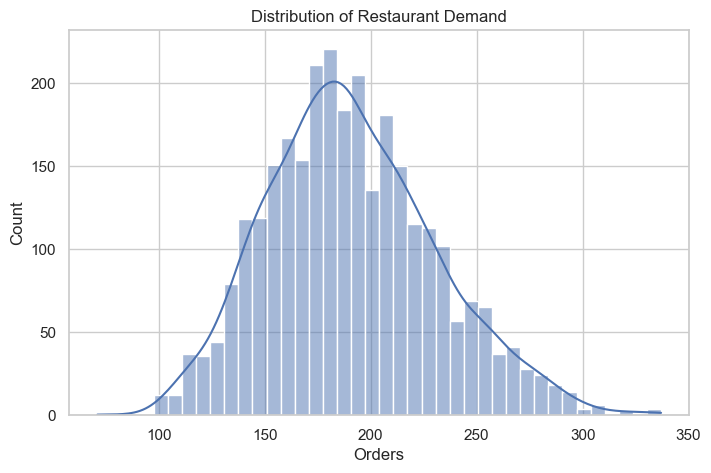

In [4]:
"""
Analyze distribution of daily restaurant demand.
"""

plt.figure(figsize=(8,5))

sns.histplot(
    df["total_orders"],
    bins=40,
    kde=True
)

plt.title("Distribution of Restaurant Demand")

plt.xlabel("Orders")

plt.show()

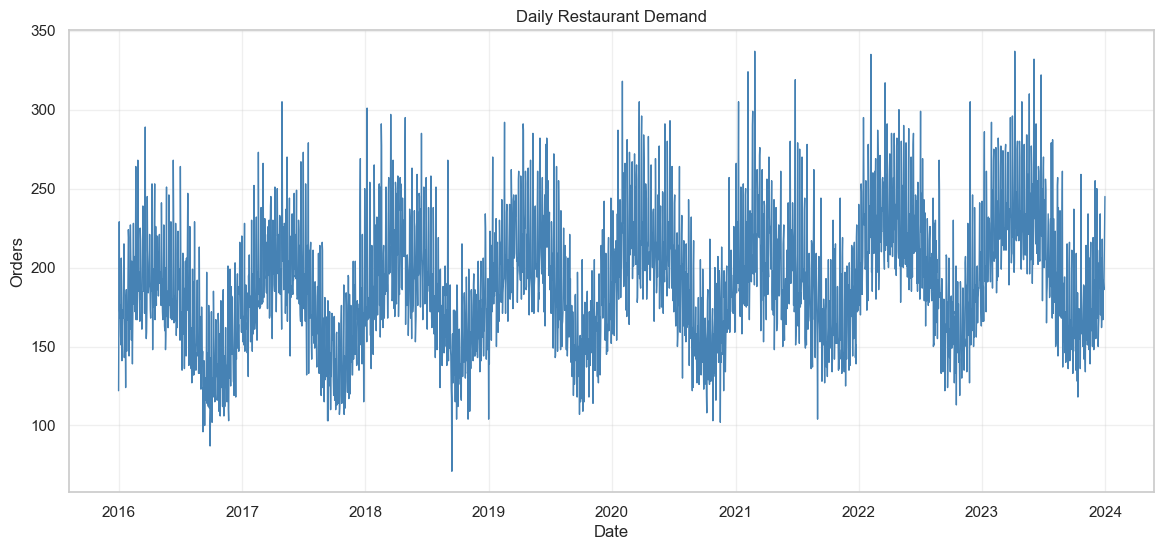

In [5]:
"""
Visualize demand over time.
"""

plt.figure(figsize=(14,6))

plt.plot(
    df["date"],
    df["total_orders"],
    color="steelblue",
    linewidth=1
)

plt.title("Daily Restaurant Demand")

plt.xlabel("Date")
plt.ylabel("Orders")

plt.grid(alpha=0.3)

plt.show()

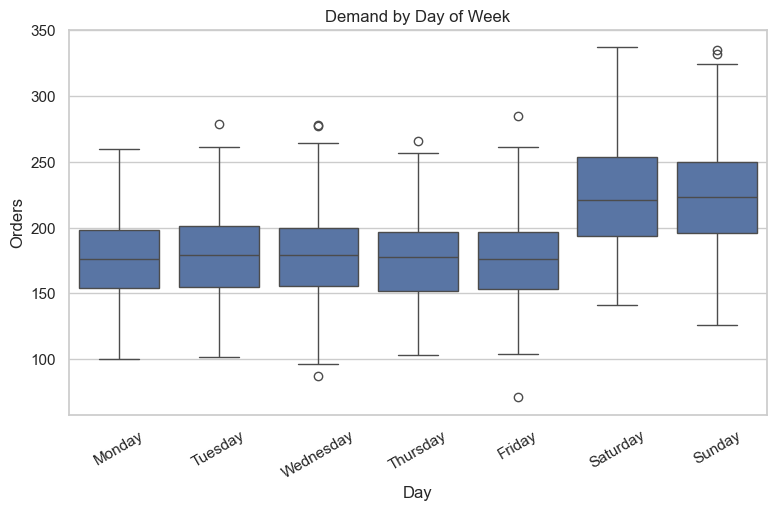

In [6]:
"""
Analyze demand patterns by day of week.
"""

plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="day_of_week",
    y="total_orders",
    order=[
        "Monday","Tuesday","Wednesday",
        "Thursday","Friday","Saturday","Sunday"
    ]
)

plt.title("Demand by Day of Week")

plt.xlabel("Day")
plt.ylabel("Orders")

plt.xticks(rotation=30)

plt.show()

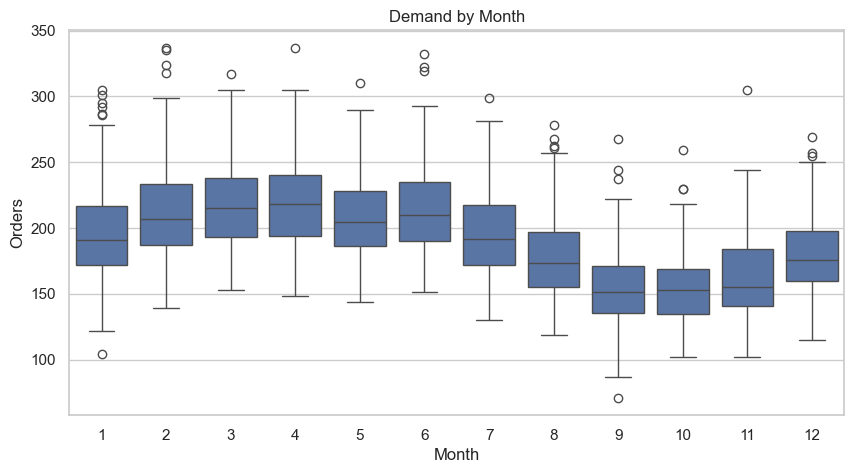

In [7]:
"""
Analyze demand patterns across months.
"""

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="month",
    y="total_orders"
)

plt.title("Demand by Month")

plt.xlabel("Month")
plt.ylabel("Orders")

plt.show()

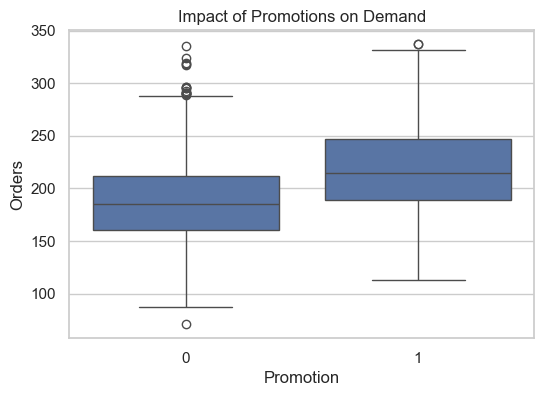

In [8]:
"""
Evaluate the effect of promotions on restaurant demand.
"""

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="promotion",
    y="total_orders"
)

plt.title("Impact of Promotions on Demand")

plt.xlabel("Promotion")
plt.ylabel("Orders")

plt.show()

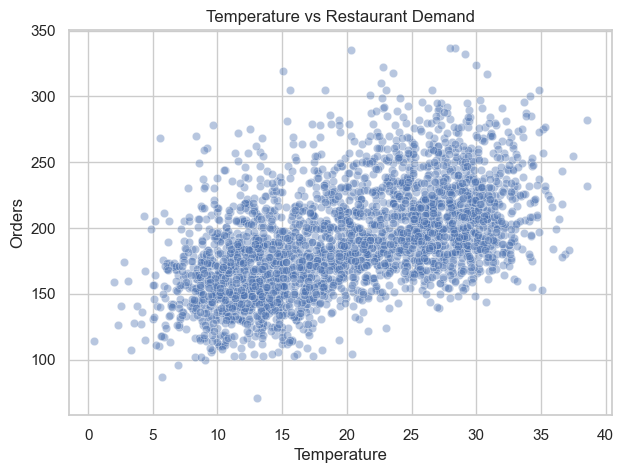

In [9]:
"""
Analyze relationship between temperature and demand.
"""

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="temperature",
    y="total_orders",
    alpha=0.4
)

plt.title("Temperature vs Restaurant Demand")

plt.xlabel("Temperature")
plt.ylabel("Orders")

plt.show()

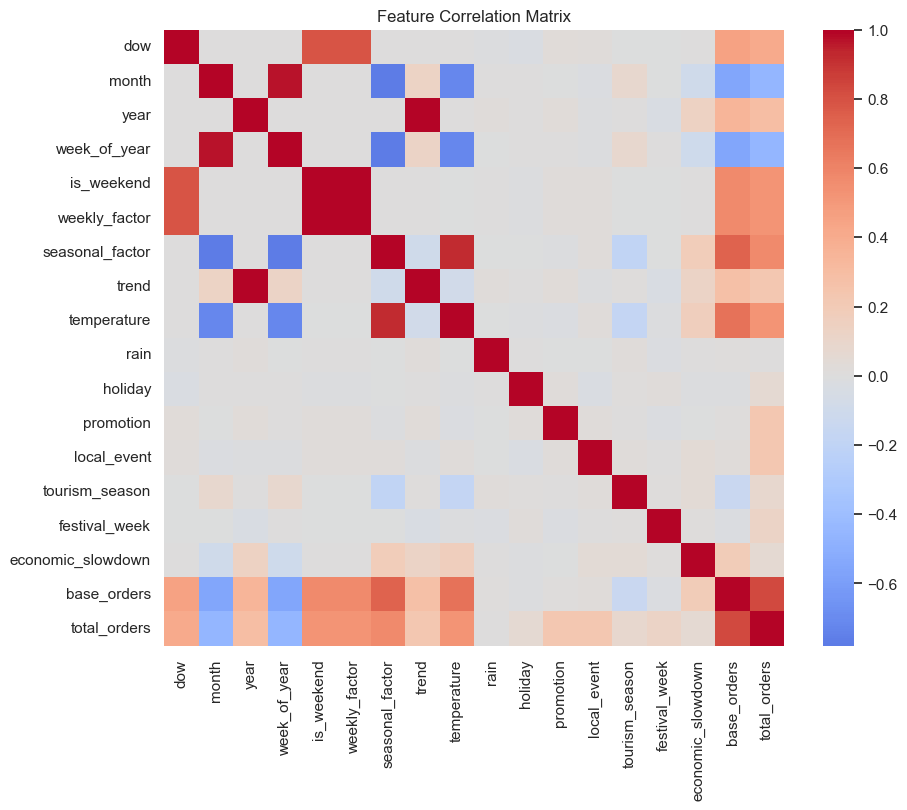

In [10]:
"""
Compute correlation matrix between numeric variables.
"""

numeric_cols = df.select_dtypes(include=["int64","float64"])

corr = numeric_cols.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

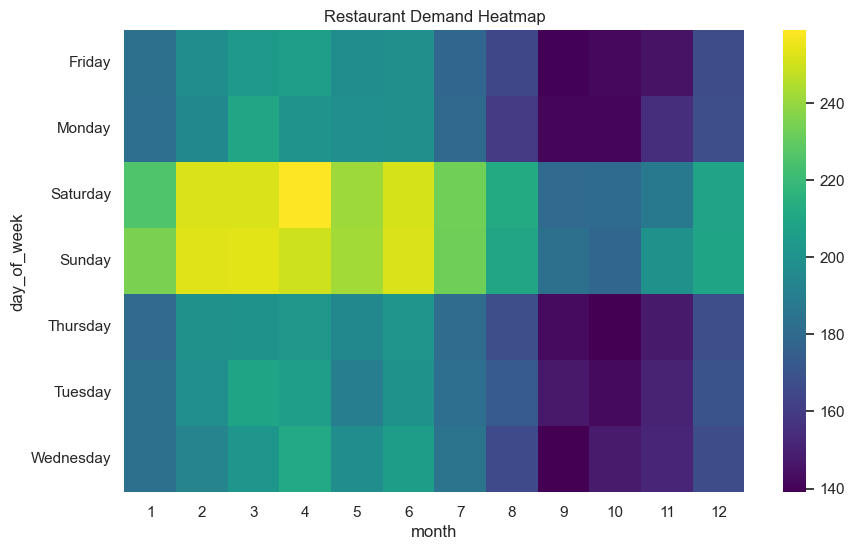

In [11]:
"""
Visualize demand intensity by day of week and month.
"""

pivot = df.pivot_table(
    values="total_orders",
    index="day_of_week",
    columns="month",
    aggfunc="mean"
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    cmap="viridis"
)

plt.title("Restaurant Demand Heatmap")

plt.show()

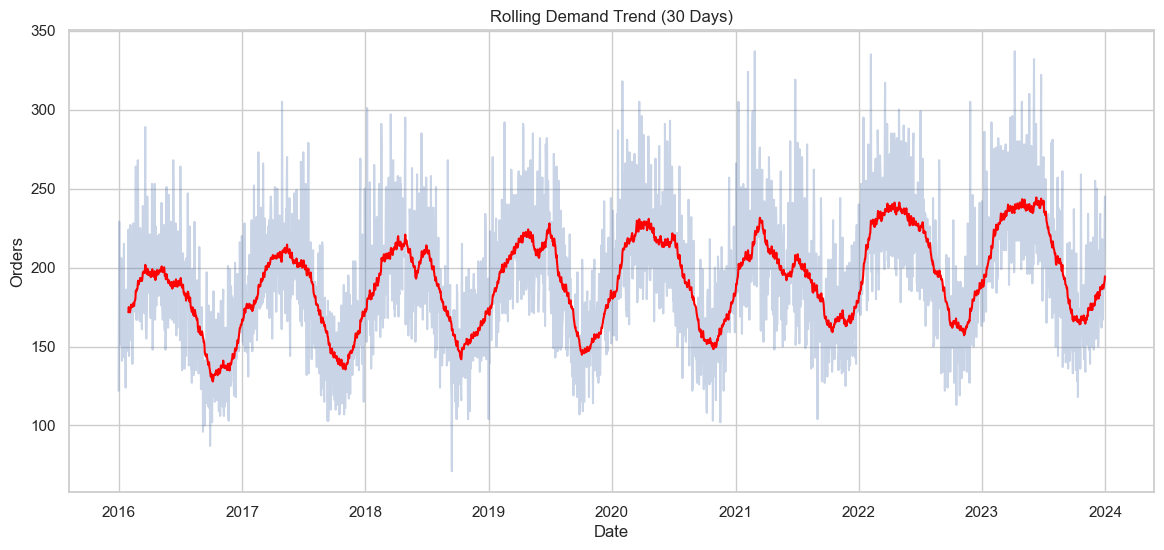

In [12]:
"""
Analyze demand volatility using rolling averages.
"""

df = df.sort_values("date")

df["rolling_mean_30"] = df["total_orders"].rolling(30).mean()

plt.figure(figsize=(14,6))

plt.plot(df["date"], df["total_orders"], alpha=0.3)

plt.plot(df["date"], df["rolling_mean_30"], color="red")

plt.title("Rolling Demand Trend (30 Days)")

plt.xlabel("Date")
plt.ylabel("Orders")

plt.show()